# Phase 0 (cont.) — 14-day series, Aarhus

Continues from [00_explore_ais_data.ipynb](00_explore_ais_data.ipynb). That exploration validated
the schema and coverage with a single day, and found that one day isn't enough for `trend_7d`
([domain/04-data-model.md](../domain/04-data-model.md)) or to assess whether traffic volume
sustains a congestion metric with real variation.

This notebook consolidates the 14 days already downloaded and filtered by
[scripts/fetch_ais.py](../scripts/fetch_ais.py) (`2025-02-13` to `2025-02-26`) to answer:
is there a real day-to-day signal, or is it flat noise?

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append("../scripts")
from fetch_ais import INTERIM_DIR, date_range

DAYS = date_range("2025-02-13", "2025-02-26")
existing = [d for d in DAYS if (INTERIM_DIR / f"aarhus-{d}.parquet").exists()]
missing = sorted(set(DAYS) - set(existing))
print(f"Days with parquet available: {len(existing)}/{len(DAYS)}")
if missing:
    print(f"Missing (not published by the source, or a download failure): {missing}")

Days with parquet available: 14/14


## 1. Consolidate via DuckDB

Instead of concatenating in pandas, we query the 14 parquet files as if they were already the
day-partitioned lake described in [domain/02-architecture.md](../domain/02-architecture.md) —
it's the same access pattern the agent's tools will use over the gold layer.

In [2]:
con = duckdb.connect()
glob_path = str(INTERIM_DIR / "aarhus-*.parquet")

con.execute(f"CREATE VIEW aarhus AS SELECT * FROM read_parquet('{glob_path}')")
con.execute("SELECT COUNT(*) AS rows FROM aarhus").df()

,rows
0,1932108


## 2. Daily series: messages and unique vessels

A simple proxy for port activity while the Phase 1 enter/exit geofencing logic doesn't exist
yet ([domain/08-phases.md](../domain/08-phases.md#phase-1--data-pipeline-bronze--silver--gold)).
If this series already shows day-to-day variation, that's a signal `trend_7d` will have real
content once it's computed over dwell time.

In [3]:
daily = con.execute("""
    SELECT
        strptime(Timestamp, '%d/%m/%Y %H:%M:%S')::DATE AS day,
        COUNT(*) AS messages,
        COUNT(DISTINCT MMSI) FILTER (WHERE \"Type of mobile\" = 'Class A') AS vessels_class_a
    FROM aarhus
    GROUP BY 1
    ORDER BY 1
""").df()
daily

,day,messages,vessels_class_a
0,2025-02-13,125674,25
1,2025-02-14,106408,23
2,2025-02-15,112136,21
3,2025-02-16,117641,21
4,2025-02-17,169137,28
5,2025-02-18,140116,25
6,2025-02-19,169265,22
7,2025-02-20,141510,24
8,2025-02-21,144610,27
9,2025-02-22,141257,25


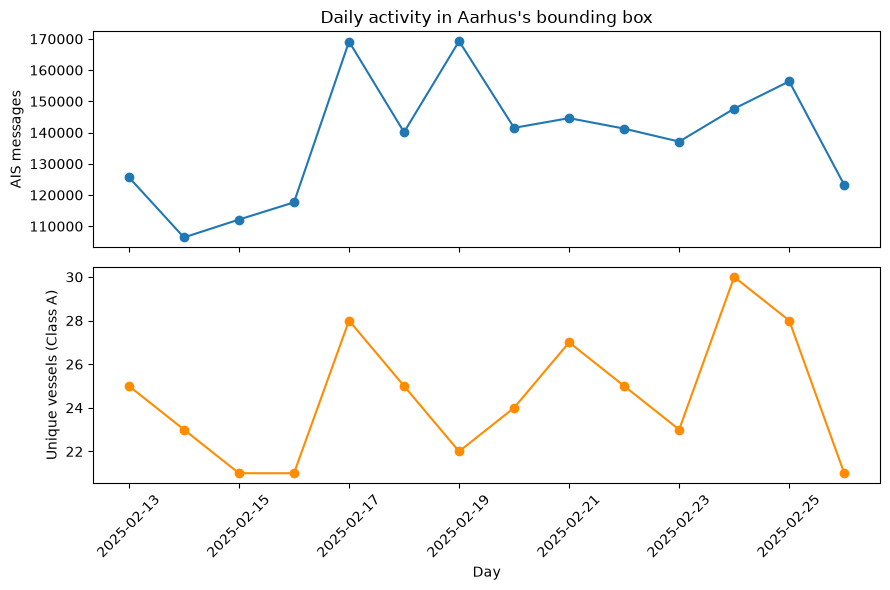

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(daily["day"], daily["messages"], marker="o")
axes[0].set_ylabel("AIS messages")
axes[0].set_title("Daily activity in Aarhus's bounding box")

axes[1].plot(daily["day"], daily["vessels_class_a"], marker="o", color="darkorange")
axes[1].set_ylabel("Unique vessels (Class A)")
axes[1].set_xlabel("Day")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

## 3. Series statistics: is there signal, or is it flat noise?

In [5]:
stats = daily["vessels_class_a"].agg(["mean", "std", "min", "max"])
cv = stats["std"] / stats["mean"]
print(stats.to_string())
print(f"\ncoefficient of variation (std/mean): {cv:.2f}")

mean    24.500000
std      2.902254
min     21.000000
max     30.000000

coefficient of variation (std/mean): 0.12


## 4. Vessels that repeat across days

If it's almost always the same MMSIs (recurring local traffic: ferries, tugs, pilots),
`vessel_history` is going to have long series for few MMSIs. If they're mostly distinct,
the pattern is passing traffic and `fct_vessel_voyage_history`
([domain/04-data-model.md](../domain/04-data-model.md)) will have many short entries.

In [6]:
vessel_days = con.execute("""
    SELECT MMSI, COUNT(DISTINCT strptime(Timestamp, '%d/%m/%Y %H:%M:%S')::DATE) AS days_present
    FROM aarhus
    WHERE \"Type of mobile\" = 'Class A'
    GROUP BY 1
    ORDER BY 2 DESC
""").df()

print(f"Unique vessels over the 14 days: {len(vessel_days)}")
print(f"Present all 14 days:             {(vessel_days['days_present'] == len(existing)).sum()}")
print(f"Present only 1 day:              {(vessel_days['days_present'] == 1).sum()}")
vessel_days.head(10)

Unique vessels over the 14 days: 87
Present all 14 days:             11
Present only 1 day:              31


,MMSI,days_present
0,219026261,14
1,219003249,14
2,219002416,14
3,219005477,14
4,219003879,14
5,219029751,14
6,219025783,14
7,219018172,14
8,219022903,14
9,219005313,14


## Conclusions (with the real 14 days, 2025-02-13 to 2025-02-26)

**The series has signal, but it's weak and low-volume — there's a pending design adjustment.**

- **Day-to-day variation — exists, but it's small.** Unique Class A vessels: mean 24.5/day,
  std dev 2.9, range 21-30. Coefficient of variation 0.12 — there's real movement (it's not a
  constant), but it's a narrow range. `trend_7d` will be computable, but at this volume
  any noise of 1-2 vessels visibly moves the %; the eval set
  ([05-agent-tools-eval.md](../domain/05-agent-tools-eval.md)) should use generous tolerances
  on this metric, not unit-level exactness.

- **A finding that changes the data model: most traffic is recurring local traffic, not
  port calls.** Of 87 unique vessels over 14 days: **11 show up all 14 days** (resident
  traffic — very likely tugs, pilotage, patrol, not "passing" vessels
  waiting their turn) and **31 show up on just one day** (those are the real candidates for
  "port call"). The MMSIs that show up every day (prefix `219...`, Danish flag) are
  consistent with local operational fleet, not international trade.

- **Direct implication for Phase 1**: if `fct_port_congestion_daily`
  ([04-data-model.md](../domain/04-data-model.md)) counts *every* vessel present, the
  "congestion" metric ends up dominated by tugs/pilotage that are there every
  day operating locally, not by vessels arriving and waiting their turn — which is what the
  metric is meant to measure. **Before writing the Phase 1 dbt model, we need to decide on a
  `Ship type` filter (or a presence-pattern filter: exclude MMSIs with `days_present` above a
  threshold) so "congestion" reflects passing commercial traffic, not the port's own service fleet.**

- **On the bounding box**: the low-volume finding from
  [00_explore_ais_data.ipynb](00_explore_ais_data.ipynb) holds even with 14 days — it
  wasn't an artifact of one atypical day. Widening it would probably add more tug/
  local pilotage traffic, not necessarily more commercial calls — it's not clear that solves the
  real problem, which is about *classifying* traffic, not geographic coverage.